# Una red neuronal a mano, con NumPy

**Facsímil 1 · Los cimientos** — capítulos 4 a 7
(la neurona, las capas, la retropropagación y los optimizadores).

Casi todo el mundo ha oído que las redes neuronales son «cajas negras» llenas de magia. Este
cuaderno desmonta esa idea construyendo una red **desde cero**, con la única ayuda de NumPy: sin
PyTorch, sin TensorFlow, sin ninguna pieza que esconda lo que pasa por dentro. Al terminar habrás
escrito tú mismo el mecanismo que mueve a *todos* los modelos modernos, desde un clasificador de
imágenes hasta un LLM. Y comprobarás que no hay magia: hay álgebra lineal, una función que curva y
una regla de tres para repartir la culpa del error.

### Qué vas a aprender
- Qué es **exactamente** una neurona artificial, escrita como una fórmula.
- Por qué una sola neurona **no puede** resolver problemas tan simples como el XOR, y qué tuvo
  paralizada a la IA durante años por culpa de esa limitación.
- Cómo una **capa oculta** rompe esa barrera, y qué significa eso geométricamente.
- Cómo funciona la **retropropagación**, derivada paso a paso, sin que sea una caja negra.
- Cómo influyen el **número de neuronas**, el **ritmo de aprendizaje** y el azar de la
  inicialización, viéndolo con experimentos que ejecutas tú.

### Qué necesitas saber antes
Solo lo del facsímil 1: que una red combina entradas con pesos, y que «entrenar» es ir corrigiendo
esos pesos. Las matemáticas (derivadas, regla de la cadena) las recordamos por el camino, con
intuición antes que con rigor.

### Cuánto cuesta
Unos 15 minutos leyéndolo con calma. Corre en CPU; no necesitas GPU ni cuenta de nada.

### Cómo encaja en el facsímil
- la **neurona** (cap. 4): la pieza que multiplica, suma y decide;
- las **capas** (cap. 5): por qué apilar neuronas da expresividad;
- la **retropropagación** (cap. 6): cómo se reparte hacia atrás la culpa del error;
- las **pérdidas y optimizadores** (cap. 7): qué medimos y cómo lo bajamos.


> **Inteligencia artificial para gente curiosa** · facsímil interactivo
> 
> Web del facsímil: https://www.iaparagentecuriosa.686f6c61.dev/ · Autor: @686f6c61 · Fecha: 2026-06-26 · Versión 1.0
> 
> Este cuaderno acompaña al facsímil: ejecútalo de arriba abajo, lee cada celda de texto
> antes de correr la de código y detente en las salidas. La gracia no es que «salga», sino
> entender *por qué* sale.

In [1]:
# En Google Colab no necesitas instalar nada: NumPy y Matplotlib ya vienen.
# En tu ordenador:  pip install numpy matplotlib
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(7)   # semilla fija: tus resultados seran identicos a los de aqui
print("NumPy", np.__version__)


NumPy 2.5.0


## 1. Qué es una neurona, en una fórmula

Despojada de toda mística, una **neurona artificial** es una función matemática que recibe varios
números de entrada y devuelve uno solo. Hace tres cosas, en este orden:

1. **Pondera y suma:** multiplica cada entrada $x_i$ por un **peso** $w_i$ (su importancia) y suma
   todo, más un término independiente $b$ llamado **sesgo** (*bias*):
$$ z = w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b = \mathbf{w}\cdot\mathbf{x} + b $$
2. **Activa:** pasa ese resultado $z$ por una **función de activación** $f$ que lo deforma. Sin
   ella, encadenar neuronas no serviría de nada (la composición de cosas lineales sigue siendo
   lineal). Usaremos la **sigmoide**, que aplasta cualquier número al intervalo $(0, 1)$, ideal
   para leerlo como una *probabilidad*:
$$ \sigma(z) = \frac{1}{1 + e^{-z}} $$
3. **Devuelve:** la salida $y = f(z)$.

Los **pesos** y el **sesgo** son los únicos números que la red *aprende*. Todo el entrenamiento
consiste en buscar los valores de $\mathbf{w}$ y $b$ que hacen que la salida se parezca a lo que
queremos. Empecemos por dibujar esa función de activación, porque su forma explica medio cuaderno.


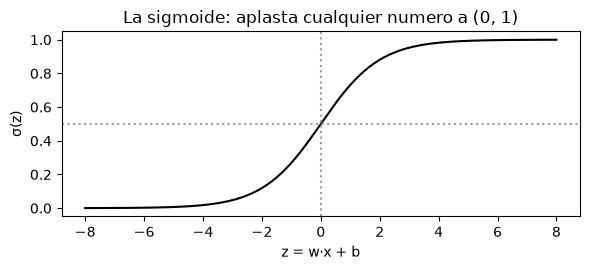

Lejos del centro decide con seguridad (0 o 1); cerca de z=0 'duda' (~0.5).


In [2]:
def sigmoide(z):
    return 1.0 / (1.0 + np.exp(-z))

zz = np.linspace(-8, 8, 200)
plt.figure(figsize=(6, 2.8))
plt.plot(zz, sigmoide(zz), color="black")
plt.axhline(0.5, ls=":", color="#9c9c9c"); plt.axvline(0, ls=":", color="#9c9c9c")
plt.title("La sigmoide: aplasta cualquier numero a (0, 1)")
plt.xlabel("z = w·x + b"); plt.ylabel("σ(z)")
plt.tight_layout(); plt.show()
print("Lejos del centro decide con seguridad (0 o 1); cerca de z=0 'duda' (~0.5).")


**Por qué esta forma importa.** Mira la curva: cuando $z$ es muy negativo, la salida es casi 0;
cuando es muy positivo, casi 1; y en torno a $z=0$ hay una transición suave. Esa suavidad es clave:
permite calcular *cuánto* mejora la salida si movemos un peso un poquito, que es justo lo que
necesita el entrenamiento. Una función con escalón brusco no daría esa información.


## 2. El problema: dos sensores y una decisión que no es una raya

Imagina un riego automático con dos lecturas binarias:

- **¿La tierra está seca?** (0 = húmeda, 1 = seca)
- **¿Va a llover pronto?** (0 = no, 1 = sí)

La regla sensata de la huerta es: **riega solo cuando las dos señales discrepan**. Si la tierra
está seca y *no* va a llover, riega. Si va a llover y la tierra ya está húmeda, no. Pero si está
seca *y* va a llover, espera; y si está húmeda y no llueve, tampoco hace falta. Esa regla de
«exactamente una de las dos» es el famoso **XOR** (*o exclusivo*).

Tiene una trampa preciosa y profunda: **no se puede separar con una sola línea recta**. Dibuja
mentalmente los cuatro casos en un cuadrado: los que hay que regar quedan en dos esquinas
*opuestas*, y los que no, en las otras dos. No existe ninguna recta que deje los «regar» a un lado
y los «no regar» al otro. En 1969, Minsky y Papert demostraron exactamente esto y hundieron durante
años el entusiasmo por las redes neuronales: la pieza básica de entonces (el perceptrón) solo sabía
trazar rectas. Vamos a revivir ese fracaso... y a superarlo.


seca=0  lluvia=0  ->  no regar
seca=0  lluvia=1  ->  REGAR
seca=1  lluvia=0  ->  REGAR
seca=1  lluvia=1  ->  no regar


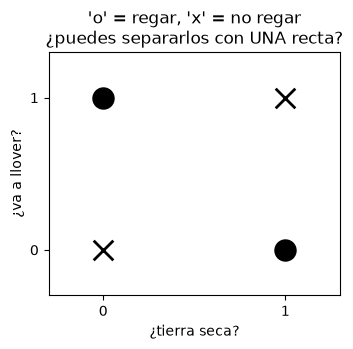

In [3]:
# Cuatro situaciones posibles (los dos sensores) y la decision correcta (regar o no)
X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]], dtype=float)
y = np.array([[0], [1], [1], [0]], dtype=float)   # 1 = regar

for (seca, lluvia), regar in zip(X, y):
    print(f"seca={int(seca)}  lluvia={int(lluvia)}  ->  {'REGAR' if regar[0] else 'no regar'}")

plt.figure(figsize=(3.6, 3.6))
for (sx, sy), t in zip(X, y):
    plt.scatter(sx, sy, c="black", marker=("o" if t[0] else "x"), s=200, linewidths=2)
plt.xticks([0,1]); plt.yticks([0,1]); plt.xlim(-0.3,1.3); plt.ylim(-0.3,1.3)
plt.xlabel("¿tierra seca?"); plt.ylabel("¿va a llover?")
plt.title("'o' = regar, 'x' = no regar\n¿puedes separarlos con UNA recta?")
plt.tight_layout(); plt.show()


Tómate un segundo con ese dibujo: los círculos están en las esquinas (0,1) y (1,0); las equis,
en (0,0) y (1,1). Cualquier recta que intentes trazar dejará siempre un círculo y una equis del
mismo lado. **Esa es la imposibilidad que vamos a medir ahora con una neurona.**


## 3. Intento 1: una sola neurona (un perceptrón logístico)

Vamos a entrenar una única neurona y a ponerle número a su fracaso. Necesitamos dos ingredientes
nuevos del capítulo 7:

**La pérdida.** Para entrenar hace falta una medida de «cómo de mal lo estamos haciendo». Usamos la
**entropía cruzada binaria**, que para una predicción $p$ y una etiqueta real $y\in\{0,1\}$ vale:
$$ L = -\big[\, y\,\log p + (1-y)\,\log(1-p) \,\big] $$
Castiga con fuerza estar *seguro y equivocado* (predecir $p\approx 1$ cuando $y=0$ dispara el
$\log$ a infinito) y premia acertar con confianza. Es la pérdida estándar para clasificación.

**El gradiente.** Entrenar es bajar esa pérdida. La derivada nos dice hacia dónde moverla. Con la
sigmoide y la entropía cruzada ocurre una preciosa simplificación: la derivada de la pérdida
respecto a $z$ es, simplemente, $p - y$ (lo que predijo menos lo que debía). Ese «error» es lo que
empuja los pesos. Repetimos el ajuste miles de veces (*descenso de gradiente*).

Fíjate en el techo: por mucho que entrene, no pasará de acertar 2 de 4.


In [4]:
# Una neurona: 2 pesos + 1 sesgo
w = np.random.randn(2, 1) * 0.5
b = np.zeros((1, 1))
lr = 0.5
historial_1 = []

for epoca in range(5000):
    z = X @ w + b
    p = sigmoide(z)                 # probabilidad de "regar"
    perdida = -np.mean(y*np.log(p+1e-9) + (1-y)*np.log(1-p+1e-9))
    historial_1.append(perdida)
    dz = (p - y) / len(X)           # gradiente respecto a z = (prediccion - real)
    w -= lr * (X.T @ dz)
    b -= lr * dz.sum(axis=0, keepdims=True)

p = sigmoide(X @ w + b)
aciertos = int(((p > 0.5).astype(float) == y).sum())
print("Probabilidades que da la neurona:", np.round(p.ravel(), 3))
print(f"Aciertos: {aciertos} de 4")
print(f"Pérdida final: {historial_1[-1]:.4f}  (no baja de ahi por mas que entrene)")


Probabilidades que da la neurona: [0.5 0.5 0.5 0.5]
Aciertos: 2 de 4
Pérdida final: 0.6931  (no baja de ahi por mas que entrene)


**Léelo despacio.** La neurona devuelve probabilidades pegadas a 0.5: está *encogiéndose de
hombros*. No es que entrene poco; es que el problema **no es separable por una línea** y una neurona
solo sabe trazar líneas. Veámoslo literalmente: dibujamos la frontera que ha aprendido (la línea
donde decide que la probabilidad es 0.5). Será una recta, y ninguna recta puede separar el XOR.


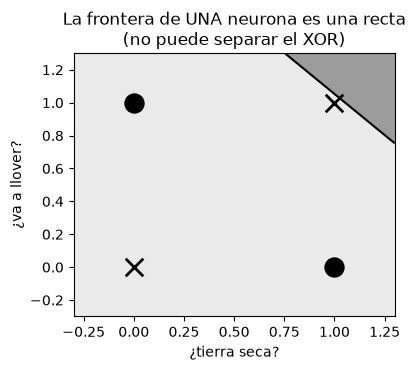

In [5]:
gx, gy = np.meshgrid(np.linspace(-0.3, 1.3, 200), np.linspace(-0.3, 1.3, 200))
malla = np.c_[gx.ravel(), gy.ravel()]
pm = sigmoide(malla @ w + b).reshape(gx.shape)
plt.figure(figsize=(4.2, 3.8))
plt.contourf(gx, gy, pm, levels=[0,0.5,1], colors=["#eaeaea", "#9c9c9c"])
plt.contour(gx, gy, pm, levels=[0.5], colors="black")
for (sx, sy), t in zip(X, y):
    plt.scatter(sx, sy, c="black", marker=("o" if t[0] else "x"), s=160, linewidths=2)
plt.title("La frontera de UNA neurona es una recta\n(no puede separar el XOR)")
plt.xlabel("¿tierra seca?"); plt.ylabel("¿va a llover?")
plt.tight_layout(); plt.show()


Ahí está el muro histórico, dibujado: la recta deja siempre mal clasificado algún punto. Durante
años se pensó que esto condenaba a las redes neuronales. La salida de este experimento no es «1+1=2»;
es un sistema que te confiesa, con números, que no puede. La solución llegó al **apilar** neuronas.


## 4. Por qué una capa oculta lo cambia todo

La idea es **componer**. Si pones varias neuronas en una capa intermedia (la *capa oculta*), cada
una traza su propia recta; una neurona final combina esas rectas y, juntas, pueden encerrar regiones
con forma **curva**. Esto no es un truco: el *teorema de aproximación universal* dice que una red con
una capa oculta suficientemente grande puede aproximar prácticamente cualquier función. Para el XOR
nos bastan **cuatro** neuronas ocultas.

Nuestra red será $2 \to 4 \to 1$: dos entradas, cuatro neuronas ocultas, una salida. El paso hacia
delante (*forward*) es solo encadenar dos veces «pondera, suma, activa»:
$$ \mathbf{a}_1 = \sigma(\mathbf{x}\,W_1 + \mathbf{b}_1) \quad\rightarrow\quad p = \sigma(\mathbf{a}_1 W_2 + b_2) $$
donde $W_1$ es $2\times4$, $W_2$ es $4\times1$. Las dimensiones encajan como piezas de Lego.


In [6]:
def init(n_in, n_out):
    # inicializacion pequena y aleatoria; la escala cuida que no se sature la sigmoide
    return np.random.randn(n_in, n_out) * np.sqrt(2.0 / n_in), np.zeros((1, n_out))

W1, b1 = init(2, 4)   # entrada -> capa oculta (4 neuronas)
W2, b2 = init(4, 1)   # capa oculta -> salida
print("Pesos creados:")
print("  W1:", W1.shape, "(2 entradas -> 4 ocultas)")
print("  W2:", W2.shape, "(4 ocultas  -> 1 salida)")
print("En total,", W1.size + b1.size + W2.size + b2.size, "numeros que la red va a aprender.")


Pesos creados:
  W1: (2, 4) (2 entradas -> 4 ocultas)
  W2: (4, 1) (4 ocultas  -> 1 salida)
En total, 17 numeros que la red va a aprender.


## 5. La retropropagación, sin caja negra

Para entrenar la red necesitamos saber cuánto culpa de la pérdida tiene **cada** peso, incluidos los
de la capa oculta, que están «escondidos» detrás de la salida. La herramienta es la **regla de la
cadena** del cálculo: si la pérdida depende de la salida, la salida de la capa oculta, y la capa
oculta de los pesos, podemos encadenar las derivadas hacia atrás. Eso es la **retropropagación**.

Paso a paso, lo que calculamos en cada época es:

1. **Forward:** $z_1 = xW_1+b_1$, $a_1 = \sigma(z_1)$, $z_2 = a_1W_2+b_2$, $p=\sigma(z_2)$.
2. **Error en la salida:** $\delta_2 = p - y$ (igual que con una neurona).
3. **Gradientes de la última capa:** $\nabla W_2 = a_1^\top \delta_2$, y se propaga el error hacia
   atrás: $\delta_1 = (\delta_2 W_2^\top)\cdot \sigma'(z_1)$, donde $\sigma'=\sigma(1-\sigma)$ es la
   derivada de la sigmoide.
4. **Gradientes de la capa oculta:** $\nabla W_1 = x^\top \delta_1$.
5. **Actualización:** cada peso baja un poquito en la dirección de su gradiente (descenso de
   gradiente con ritmo `lr`).

Lo escribimos tal cual. Cada línea de la parte «hacia atrás» es una de esas fórmulas.


In [7]:
W1, b1 = init(2, 4); W2, b2 = init(4, 1)   # reiniciamos por si reejecutas
lr = 1.0
historial = []

for epoca in range(8000):
    # --- hacia delante (forward) ---
    z1 = X @ W1 + b1
    a1 = sigmoide(z1)            # activaciones de la capa oculta
    z2 = a1 @ W2 + b2
    p  = sigmoide(z2)            # probabilidad final

    # --- perdida: entropia cruzada binaria ---
    perdida = -np.mean(y*np.log(p+1e-9) + (1-y)*np.log(1-p+1e-9))
    historial.append(perdida)

    # --- hacia atras (retropropagacion = regla de la cadena) ---
    d2 = (p - y) / len(X)              # error en la salida
    dW2 = a1.T @ d2
    db2 = d2.sum(axis=0, keepdims=True)
    d1 = (d2 @ W2.T) * a1 * (1 - a1)   # error propagado * derivada de la sigmoide
    dW1 = X.T @ d1
    db1 = d1.sum(axis=0, keepdims=True)

    # --- paso del optimizador (descenso de gradiente) ---
    W2 -= lr * dW2; b2 -= lr * db2
    W1 -= lr * dW1; b1 -= lr * db1

def predice(M):
    return sigmoide(sigmoide(M @ W1 + b1) @ W2 + b2)

p = predice(X)
aciertos = int(((p > 0.5).astype(float) == y).sum())
print("Probabilidades de la red:", np.round(p.ravel(), 3))
print(f"Aciertos: {aciertos} de 4")
print(f"Pérdida inicial: {historial[0]:.3f}  ->  pérdida final: {historial[-1]:.4f}")


Probabilidades de la red: [0.001 0.999 1.    0.001]
Aciertos: 4 de 4
Pérdida inicial: 0.753  ->  pérdida final: 0.0010


**Lo que acaba de pasar** es el corazón del facsímil 1: las cuatro neuronas ocultas se reparten
el trabajo, la última las combina, y la frontera deja de ser una raya. Las probabilidades ahora se
van a los extremos (cerca de 0 o de 1): la red **está segura**, y acierta las cuatro. La pérdida ha
caído un par de órdenes de magnitud. Lo notable es que no programamos *cómo* resolver el XOR: solo
definimos la arquitectura y dejamos que la retropropagación encontrara los pesos.


## 6. El aprendizaje, en una curva

Cada punto de esta curva es una época: medir el error y dar un pasito que lo reduce, ocho mil veces.
Esa caída *es* el entrenamiento (capítulo 7). Comparamos, en la misma gráfica, la red (que aprende) y
la neurona sola (que se atasca arriba).


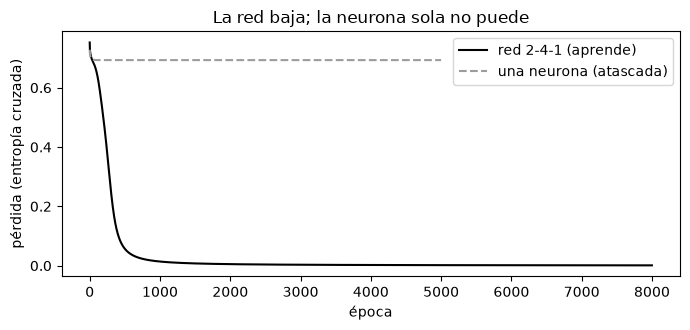

In [8]:
plt.figure(figsize=(7, 3.4))
plt.plot(historial, color="black", label="red 2-4-1 (aprende)")
plt.plot(historial_1, color="#9c9c9c", ls="--", label="una neurona (atascada)")
plt.xlabel("época"); plt.ylabel("pérdida (entropía cruzada)")
plt.title("La red baja; la neurona sola no puede"); plt.legend()
plt.tight_layout(); plt.show()


## 7. La frontera curva, y lo que ve cada neurona oculta

Pintamos, para cada punto del plano, qué decidiría la red. La frontera **se curva**: eso es lo que
una sola neurona no podía. Y, a su lado, dibujamos la recta que ha aprendido **cada una** de las 4
neuronas ocultas: la red combina esas cuatro rectas para encerrar las regiones correctas. Ahí ves,
literalmente, cómo la composición crea la no-linealidad.


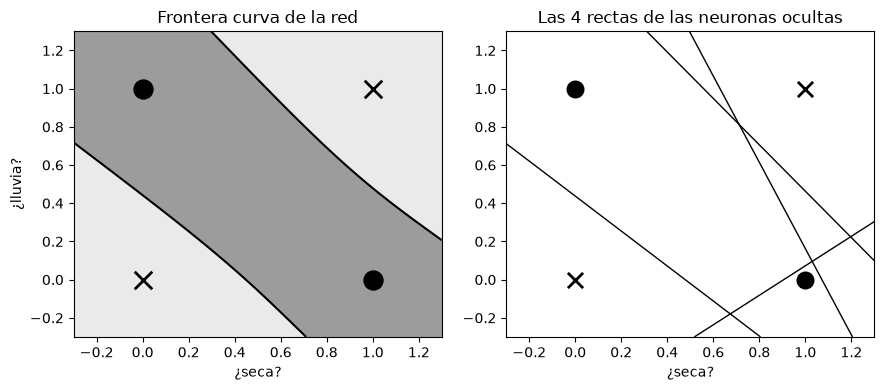

In [9]:
gx, gy = np.meshgrid(np.linspace(-0.3, 1.3, 200), np.linspace(-0.3, 1.3, 200))
malla = np.c_[gx.ravel(), gy.ravel()]
pm = predice(malla).reshape(gx.shape)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4))
ax1.contourf(gx, gy, pm, levels=[0,0.5,1], colors=["#eaeaea", "#9c9c9c"])
ax1.contour(gx, gy, pm, levels=[0.5], colors="black", linewidths=1.5)
for (sx, sy), t in zip(X, y):
    ax1.scatter(sx, sy, c="black", marker=("o" if t[0] else "x"), s=160, linewidths=2)
ax1.set_title("Frontera curva de la red"); ax1.set_xlabel("¿seca?"); ax1.set_ylabel("¿lluvia?")

# las 4 rectas de las neuronas ocultas (donde cada una vale 0.5)
a1_malla = sigmoide(malla @ W1 + b1).reshape(200, 200, 4)
for k in range(4):
    ax2.contour(gx, gy, a1_malla[:,:,k], levels=[0.5], colors="black", linewidths=1)
for (sx, sy), t in zip(X, y):
    ax2.scatter(sx, sy, c="black", marker=("o" if t[0] else "x"), s=120, linewidths=2)
ax2.set_title("Las 4 rectas de las neuronas ocultas"); ax2.set_xlabel("¿seca?")
plt.tight_layout(); plt.show()


## 8. Experimentos: ¿cuánta red hace falta?

Hasta aquí hemos fijado 4 neuronas ocultas. ¿Y si ponemos menos? ¿Y más? En vez de creerte la
respuesta, la ejecutamos: entrenamos la misma red con 1, 2, 3, 4 y 8 neuronas ocultas, varias veces
cada una (porque el azar de la inicialización importa), y miramos cuántas veces logra resolver el
XOR. Esto es lo que de verdad significa «la profundidad/anchura no es un adorno».


In [10]:
def entrena(n_ocultas, semilla, epocas=8000, lr=1.0):
    rng = np.random.default_rng(semilla)
    W1 = rng.standard_normal((2, n_ocultas)) * np.sqrt(2/2); b1 = np.zeros((1, n_ocultas))
    W2 = rng.standard_normal((n_ocultas, 1)) * np.sqrt(2/n_ocultas); b2 = np.zeros((1, 1))
    for _ in range(epocas):
        a1 = sigmoide(X @ W1 + b1); p = sigmoide(a1 @ W2 + b2)
        d2 = (p - y) / len(X)
        d1 = (d2 @ W2.T) * a1 * (1 - a1)
        W2 -= lr * (a1.T @ d2); b2 -= lr * d2.sum(0, keepdims=True)
        W1 -= lr * (X.T @ d1); b1 -= lr * d1.sum(0, keepdims=True)
    p = sigmoide(sigmoide(X @ W1 + b1) @ W2 + b2)
    return int(((p > 0.5).astype(float) == y).sum())

print("neuronas |  veces que resuelve el XOR (de 10 arranques distintos)")
for n in [1, 2, 3, 4, 8]:
    exitos = sum(entrena(n, s) == 4 for s in range(10))
    print(f"   {n:>2}    |  {'#'*exitos:<10} {exitos}/10")


neuronas |  veces que resuelve el XOR (de 10 arranques distintos)


    1    |             0/10


    2    |  #########  9/10


    3    |  #########  9/10


    4    |  ########## 10/10


    8    |  ########## 10/10


**Lee la tabla.** Con **1** neurona nunca lo resuelve (era de esperar: una recta). Con **2** ya lo
consigue algunas veces, pero falla en otras: tan justa de capacidad que, según dónde caiga la
inicialización aleatoria, se queda atascada en una mala solución. A partir de **4** lo resuelve casi
siempre, y con **8** prácticamente siempre. Dos lecciones de oro: (1) más capacidad ayuda hasta cierto
punto; (2) el **azar de la inicialización** es real: la misma red puede aprender o atascarse según el
punto de partida. Por eso, en la práctica, se entrena varias veces o se usan buenas inicializaciones.


## 9. Pruébalo tú

1. **Sube el ritmo de aprendizaje** a `lr = 10` en la celda de entrenamiento principal y mira la
   curva de pérdida. ¿Aprende más rápido o se vuelve inestable y rebota? Ese es, en miniatura, el
   dilema que resuelven los optimizadores avanzados (Adam y compañía, capítulo 7).
2. **Cambia la función de activación** de la capa oculta por una ReLU (`np.maximum(0, z)`) y ajusta su
   derivada (1 si z>0, 0 si no). Es la activación que usan casi todas las redes modernas. ¿Aprende
   igual de bien? ¿Más rápido?
3. **Aumenta el ruido del problema:** añade un quinto y un sexto punto «intermedios» y reentrena.
   ¿Sigue encontrando una frontera razonable?
4. **Cambia la semilla** (`np.random.seed`) y observa si alguna vez la red de 4 neuronas se atasca.
   Conecta esto con la tabla del experimento anterior.


## 10. Errores comunes (y por qué pasan)

- **«No aprende nada, la pérdida no baja».** Suele ser un ritmo de aprendizaje demasiado bajo (avanza
  a paso de tortuga) o una mala inicialización. Sube `lr` o cambia la semilla.
- **«La pérdida explota o sale NaN».** Ritmo demasiado alto: los pasos son tan grandes que el modelo
  se desestabiliza. Bájalo.
- **«Acierta el entrenamiento pero da igual».** Con solo 4 puntos no hay «datos nuevos» que medir; en
  problemas reales, acertar el entrenamiento no garantiza generalizar (eso es el cuaderno del
  sobreajuste de este mismo facsímil).
- **«Mi red de 2 neuronas a veces falla».** No es un bug: es capacidad justa + azar. Lo viste en la
  tabla.


## 11. Qué te llevas

- Una **neurona** traza una raya ($\sigma(\mathbf{w}\cdot\mathbf{x}+b)$). Para problemas que no son una
  raya —y casi ninguno interesante lo es— necesitas **capas**: ahí nace la expresividad, y el XOR es el
  ejemplo mínimo que lo demuestra.
- **Entrenar** es medir el error con una **pérdida** y bajarlo a pasitos con un **optimizador**; la
  **retropropagación** es la contabilidad (regla de la cadena) que reparte ese error hacia atrás,
  capa por capa.
- Lo escribiste **a mano**: cuando uses PyTorch o TensorFlow, sabrás que por dentro hacen exactamente
  esto —forward, pérdida, gradientes, paso— solo que más rápido, con más capas y calculando las
  derivadas automáticamente (*autograd*).
- El **azar** (inicialización) y los **hiperparámetros** (ritmo, número de neuronas) no son detalles:
  deciden si la red aprende o se atasca.

**Para seguir en el facsímil:** el cap. 8 (CNNs y RNNs) reutiliza estas mismas ideas con otra forma; el
cap. 9 (tokens y *embeddings*) cambia los «sensores» por representaciones del lenguaje; y el facsímil 3
abre por dentro un Transformer, que no deja de ser muchas de estas capas bien colocadas, con la
atención como pegamento.


---

### Ficha del cuaderno

- **Obra:** *Inteligencia artificial para gente curiosa* (facsímil interactivo).
- **Web:** https://www.iaparagentecuriosa.686f6c61.dev/
- **Autor:** @686f6c61
- **Fecha:** 2026-06-26
- **Versión:** 1.0

*Material pedagógico. Las salidas que ves son reales: se generan al ejecutar el código, no están escritas a mano. Si cambias algo, cambiarán: esa es la idea.*